# Phase 6 — Notebook 25b: explainer control + regime diagnostic on CSE-CIC-IDS2018

**Notebook:** `notebooks/08_phase6_cse2018/25b_cse2018_explainer_control.ipynb`
**Trigger:** notebook 25's pre-registered P6 fired — the MLP domain-SHAP beat KS on 2018 (KS−dom = −0.125). Per Addendum A2.4 the explainer control runs **before any interpretation**. Faithful clone of notebook 13b on the 2018 arms, plus the regime diagnostic that the CICIDS/UNSW contrast used.

**Part 1 — explainer control (13b design, D031 gate, margin 0.05).** For the *same* pre-vs-post domain classifier of each model class, compute domain-SHAP two ways against the same Wasserstein truth: TreeSHAP (trees) and the model-agnostic PermutationExplainer (all three). Δ = KS − domain-SHAP under PermutationExplainer:
- **EXPLAINER-DRIVEN** iff Δ_rf < −m AND Δ_xgb < −m AND Δ_mlp < −m (everyone flips under the marginal explainer).
- **MODEL-DRIVEN** iff Δ_rf ≥ −m AND Δ_xgb ≥ −m AND Δ_mlp < −m (only the MLP beats KS — a genuine model-class effect, as on UNSW and CICIDS).
- **MIXED** otherwise.

**Part 2 — regime diagnostic (drift marginality).** Places 2018 on the marginality axis that explains the KS swing across datasets (§IV-G): per-arm max/mean per-feature KS and Wasserstein between the anchor pre/post windows, and per-arm method scores from `25_cse2018_raw.csv`. Expectation under the paper's mechanism: 2018's injected families produce UNSW-like weak marginal shift (KS 0.425 ≈ UNSW's 0.411, far from CICIDS's 0.700), with per-arm variation (DoS/Hulk likely the most marginal, Bot/Infiltration the least).

**Runtime:** ~15–25 min (PermutationExplainer on trees dominates).

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap xgboost

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr, wasserstein_distance

from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.data.loaders import load_dataset, CSE2018_DAY_ORDER
from src.divergence.localization import (
    shap_importance, ks_drift_scores, topk_indices, precision_at_k,
    random_precision_expectation, agnostic_shap_importance,
)

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase6_25b_cse2018_explainer_control.json'

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    RF_PARAMS = json.load(f)['rf_hyperparameters']

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)
MODEL_COLOR = {'rf': '#E69F00', 'xgb': '#009E73', 'mlp': '#56B4E9'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='25b_cse2018_explainer_control'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today} \u2014 {context}\n\n'
             f'**Decision.** {decision}\n\n**Rationale.** {rationale}\n')
    if alternatives:
        entry += f'\n**Alternatives considered.** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as fh:
        fh.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

## 2. Decision record (set the next free ID)

In [3]:
log_decision(
    decision_id='D032',   # <-- bump if taken
    decision=(
        'Run the 13b explainer control on the CSE-CIC-IDS2018 arms after notebook 25 '
        'P6 fired (MLP domain-SHAP beat KS, KS-dom = -0.125). Same domain classifier '
        'per model, domain-SHAP via TreeSHAP (trees) and PermutationExplainer (all), '
        'scored against the same Wasserstein anchor, arms {DoS, DDoS, Infiltration, '
        'Bot}, seeds {42,1,7}, margin 0.05, gate identical to D031 (EXPLAINER-DRIVEN / '
        'MODEL-DRIVEN / MIXED). Additionally compute the per-arm drift-marginality '
        'diagnostic (max/mean per-feature KS and Wasserstein of each injected family) '
        'to place 2018 on the marginality axis of the section IV-G mechanism.'
    ),
    rationale=(
        'A2.4 requires the explainer control before interpreting a P6 MLP win. The '
        'marginality diagnostic converts the three-dataset outcome (UNSW: MLP wins, '
        'CICIDS: KS wins, 2018: MLP wins) from a vote count into a mechanism curve: '
        'MLP domain-SHAP is regime-invariant (~0.55-0.59) while KS tracks marginal '
        'shift strength (0.411 / 0.700 / 0.425).'
    ),
)

[DECISION SKIPPED] D032 already logged.


## 3. Configuration + working pool (identical to notebook 25 v2)

In [4]:
set_global_seed(42)

WINDOW = 4000
INJECT_P = 0.5
ANCHOR_N = 4000
SHAP_SAMPLE = 800
SEEDS = [42, 1, 7]
MODELS = ['rf', 'xgb', 'mlp']
K_PRIMARY = 10
MARGIN = 0.05
ARMS = ['DoS', 'DDoS', 'Infiltration', 'Bot']
POOL_PER_DAY = 200_000

MLP_PARAMS = dict(hidden_layer_sizes=(256, 128, 64), activation='relu',
                  alpha=1e-4, max_iter=300, early_stopping=True,
                  n_iter_no_change=15, random_state=42)

In [5]:
# v2 pool builder — byte-identical to notebook 25 v2 so windows match.
fam_map_df = pd.read_csv(TABLES / '24_family_map.csv')
CAT_TO_FAM = dict(zip(fam_map_df['attack_category'], fam_map_df['family']))

pool_X, pool_y, pool_fam = [], [], []
for day in CSE2018_DAY_ORDER:
    X_d, y_d, meta_d = load_dataset('cse_cic_ids2018', day=day)
    cats = meta_d['attack_category'].astype(str)
    fam_d = np.where(y_d.values == 1,
                     cats.map(CAT_TO_FAM).fillna('UNMAPPED').values, 'BENIGN')
    arm_idx = np.flatnonzero(np.isin(fam_d, ARMS))
    rest_idx = np.setdiff1d(np.arange(len(y_d)), arm_idx)
    n_fill = max(0, POOL_PER_DAY - len(arm_idx))
    if len(rest_idx) > n_fill:
        frac = n_fill / len(rest_idx)
        fill = (pd.Series(rest_idx)
                  .groupby(cats.iloc[rest_idx].values, group_keys=False)
                  .apply(lambda g: g.sample(max(1, int(round(len(g)*frac))),
                                            random_state=42)).values)
    else:
        fill = rest_idx
    keep = np.concatenate([arm_idx, fill])
    pool_X.append(X_d.iloc[keep].to_numpy(dtype=np.float32))
    pool_y.append(y_d.iloc[keep].to_numpy())
    pool_fam.append(fam_d[keep])
    del X_d, y_d, meta_d

Xall = np.vstack(pool_X); y = np.concatenate(pool_y); fam = np.concatenate(pool_fam)
del pool_X, pool_y, pool_fam
N_FEATURES = Xall.shape[1]
mu, sd = Xall.mean(0), Xall.std(0); sd[sd == 0] = 1.0
Xz = ((Xall - mu) / sd).astype(np.float32); del Xall
CHANCE = random_precision_expectation(K_PRIMARY, N_FEATURES)
benign_mask = (y == 0)
print(f'pool {Xz.shape} | chance {CHANCE:.3f}')

pool (2199584, 82) | chance 0.122


## 4. Part 1 — the control (same domain classifier, two explainers; 13b verbatim)

In [6]:
def make_model(kind, seed):
    if kind == 'rf':
        return RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed})
    if kind == 'mlp':
        return MLPClassifier(**{**MLP_PARAMS, 'random_state': seed})
    from xgboost import XGBClassifier
    return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                         subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
                         tree_method='hist', random_state=seed, eval_metric='logloss')

def norm(v):
    v = np.abs(np.asarray(v, float)); s = v.sum(); return v / s if s > 0 else v

def take(pool, n, rng):
    idx = rng.choice(pool, size=min(n, len(pool)), replace=False)
    return Xz[idx], (~benign_mask[idx]).astype(int)

def additive_post(base_pool, hold_pool, n, rng):
    n_h = int(round(n * INJECT_P)); n_b = n - n_h
    bX, by = take(base_pool, n_b, rng); hX, hy = take(hold_pool, n_h, rng)
    X = np.vstack([bX, hX]); yids = np.concatenate([by, hy])
    order = rng.permutation(len(X)); return X[order], yids[order]

rows, marg = [], []
t0 = time.time()
for H in ARMS:
    base_pool = np.where(benign_mask | (fam != H))[0]
    hold_pool = np.where((~benign_mask) & (fam == H))[0]

    arng = np.random.default_rng(777)
    preA, _ = take(base_pool, ANCHOR_N, arng)
    postA, _ = additive_post(base_pool, hold_pool, ANCHOR_N, arng)
    wass_raw = np.array([wasserstein_distance(preA[:, j], postA[:, j])
                         for j in range(N_FEATURES)])
    wass = norm(wass_raw)
    gt_set = set(int(i) for i in topk_indices(wass, K_PRIMARY))

    # --- Part 2 input: per-arm marginality of the injected drift ---
    ks_anchor = ks_drift_scores(preA, postA)
    marg.append({'family': H,
                 'ks_max': float(ks_anchor.max()),
                 'ks_mean': float(ks_anchor.mean()),
                 'ks_top10_mean': float(np.sort(ks_anchor)[-10:].mean()),
                 'wass_max_z': float(wass_raw.max()),
                 'wass_top10_mean_z': float(np.sort(wass_raw)[-10:].mean())})

    for model in MODELS:
        for seed in SEEDS:
            rng = np.random.default_rng(seed)
            preX, pre_y = take(base_pool, WINDOW, rng)
            postX, post_y = additive_post(base_pool, hold_pool, WINDOW, rng)

            domX = np.vstack([preX, postX])
            domy = np.r_[np.zeros(len(preX), int), np.ones(len(postX), int)]
            dtr, dev = train_test_split(np.arange(len(domy)), train_size=0.7,
                                        stratify=domy, random_state=seed)
            dom = make_model(model, seed).fit(domX[dtr], domy[dtr])
            di = rng.choice(dev, size=min(SHAP_SAMPLE, len(dev)), replace=False)

            ks_p = precision_at_k(ks_drift_scores(preX, postX), gt_set, K_PRIMARY)

            perm_imp = norm(agnostic_shap_importance(dom, domX[di],
                                                     X_bg=domX[dtr], seed=seed))
            rows.append({'family': H, 'model': model, 'seed': seed, 'variant': 'perm',
                         'precision': precision_at_k(perm_imp, gt_set, K_PRIMARY),
                         'ks': ks_p, 'agree_tree_perm': float('nan')})

            if model in ('rf', 'xgb'):
                tree_imp = norm(shap_importance(dom, domX[di]))
                rho = spearmanr(tree_imp, perm_imp).correlation
                rows.append({'family': H, 'model': model, 'seed': seed,
                             'variant': 'treeshap',
                             'precision': precision_at_k(tree_imp, gt_set, K_PRIMARY),
                             'ks': ks_p,
                             'agree_tree_perm': float(rho) if rho == rho else 0.0})
        print(f'  {H} / {model} done ({time.time()-t0:.0f}s)')

ctrl = pd.DataFrame(rows)
ctrl.to_csv(TABLES / '25b_explainer_control_raw.csv', index=False)
marg_df = pd.DataFrame(marg)
marg_df.to_csv(TABLES / '25b_arm_marginality.csv', index=False)
print(f'\n{len(ctrl)} control rows; marginality table written.')

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  DoS / rf done (59s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  DoS / xgb done (67s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


...

  Bot / rf done (334s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Bot / xgb done (341s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Bot / mlp done (369s)

60 control rows; marginality table written.


## 5. Verdict (13b gate, D031 form)

In [7]:
KS_MEAN = float(ctrl['ks'].mean())

def dom(model, variant):
    s = ctrl[(ctrl['model'] == model) & (ctrl['variant'] == variant)]['precision']
    return float(s.mean()) if len(s) else float('nan')

summary = {}
print(f'domain-SHAP precision@{K_PRIMARY} vs Wasserstein (KS mean {KS_MEAN:.3f}, '
      f'chance {CHANCE:.3f}):')
print(f'  {"model":<5} {"TreeSHAP":>9} {"Perm":>7}   {"KS-Tree":>8} {"KS-Perm":>8}'
      f'   {"lift(Perm-Tree)":>15}')
for model in MODELS:
    t = dom(model, 'treeshap'); p = dom(model, 'perm')
    ks_t = (KS_MEAN - t) if t == t else float('nan')
    ks_p = KS_MEAN - p
    lift = (p - t) if t == t else float('nan')
    summary[model] = {'treeshap': t, 'perm': p, 'ks_minus_tree': ks_t,
                      'ks_minus_perm': ks_p, 'perm_lift': lift}
    ts = f'{t:>9.3f}' if t == t else f'{"n/a":>9}'
    kt = f'{ks_t:>+8.3f}' if ks_t == ks_t else f'{"n/a":>8}'
    lf = f'{lift:>+15.3f}' if lift == lift else f'{"n/a":>15}'
    print(f'  {model:<5} {ts} {p:>7.3f}   {kt} {ks_p:>+8.3f}   {lf}')

print('\nSpearman(TreeSHAP, Perm) on the same domain classifier:')
tree_perm_agree = {}
for model in ('rf', 'xgb'):
    a = ctrl[(ctrl['model'] == model)
             & (ctrl['variant'] == 'treeshap')]['agree_tree_perm'].mean()
    tree_perm_agree[model] = float(a)
    print(f'  {model}: {a:.3f}')

m = MARGIN
d_rf = summary['rf']['ks_minus_perm']
d_xgb = summary['xgb']['ks_minus_perm']
d_mlp = summary['mlp']['ks_minus_perm']
trees_flip = (d_rf < -m) and (d_xgb < -m)
mlp_beats = d_mlp < -m
verdict = ('EXPLAINER-DRIVEN' if (trees_flip and mlp_beats) else
           'MODEL-DRIVEN' if ((not trees_flip) and mlp_beats) else 'MIXED')

print('\n' + '=' * 76)
print(f'2018 EXPLAINER-CONTROL VERDICT  -- precision@{K_PRIMARY} vs Wasserstein')
print('=' * 76)
print(f'  KS (model-free) {KS_MEAN:.3f} | margin {m}')
print(f'  KS - domainSHAP(Perm):  rf {d_rf:+.3f} | xgb {d_xgb:+.3f} | mlp {d_mlp:+.3f}')
print(f'  (negative = domain-SHAP beats KS under PermutationExplainer)')
print('-' * 76)
print(f'--> VERDICT: {verdict}')
print({'EXPLAINER-DRIVEN': '    the 2018 MLP win follows the explainer, not the model '
                           '(differs from UNSW/CICIDS controls -> report per-dataset).',
       'MODEL-DRIVEN': '    the 2018 MLP win is the model, matching the UNSW and '
                       'CICIDS controls -> the IV-G mechanism generalizes.',
       'MIXED': '    per-model deltas do not form a clean dichotomy -> report deltas.'
      }[verdict])

domain-SHAP precision@10 vs Wasserstein (KS mean 0.425, chance 0.122):
  model  TreeSHAP    Perm    KS-Tree  KS-Perm   lift(Perm-Tree)
  rf        0.375   0.367     +0.050   +0.058            -0.008
  xgb       0.208   0.158     +0.217   +0.267            -0.050
  mlp         n/a   0.533        n/a   -0.108               n/a

Spearman(TreeSHAP, Perm) on the same domain classifier:
  rf: 0.977
  xgb: 0.976

2018 EXPLAINER-CONTROL VERDICT  -- precision@10 vs Wasserstein
  KS (model-free) 0.425 | margin 0.05
  KS - domainSHAP(Perm):  rf +0.058 | xgb +0.267 | mlp -0.108
  (negative = domain-SHAP beats KS under PermutationExplainer)
----------------------------------------------------------------------------
--> VERDICT: MODEL-DRIVEN
    the 2018 MLP win is the model, matching the UNSW and CICIDS controls -> the IV-G mechanism generalizes.


## 6. Part 2 — regime diagnostic: where 2018 sits on the marginality axis

Reads the per-arm method scores from `25_cse2018_raw.csv` and joins them with the
per-arm marginality of the injected drift. Cross-dataset anchor points from the
paper: UNSW KS 0.411 (MLP wins), CICIDS KS 0.700 (KS wins), 2018 KS 0.425.

,ks_max,ks_mean,ks_top10_mean,wass_max_z,wass_top10_mean_z,ks_precision,domain_shap_mlp,mlp_minus_ks
family,,,,,,,,
Infiltration,0.453,0.252,0.451,2.075,1.081,0.3,0.300,0.000
Bot,0.456,0.215,0.400,0.644,0.527,0.5,0.600,0.100
DoS,0.490,0.189,0.351,0.961,0.510,0.4,0.633,0.233
DDoS,0.390,0.160,0.330,1.063,0.546,0.5,0.667,0.167


  saved: 25b_regime_diagnostic.png / .pdf


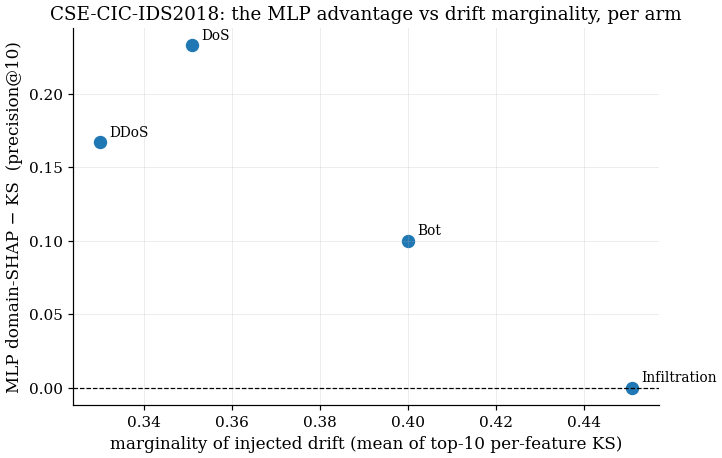

In [9]:
res25 = pd.read_csv(TABLES / '25_cse2018_raw.csv')
w = res25[res25['gt'] == 'wasserstein']
per_arm = (w.pivot_table(index='family', columns='method', values='precision')
             [['ks', 'domain_shap', 'dual_ids']].round(3))
per_arm_mlp = (w[w['model'] == 'mlp']
               .pivot_table(index='family', columns='method', values='precision')
               [['ks', 'domain_shap']].round(3)
               .rename(columns={'domain_shap': 'domain_shap_mlp'}))
diag = (marg_df.set_index('family')
        .join(per_arm[['ks']].rename(columns={'ks': 'ks_precision'}))
        .join(per_arm_mlp[['domain_shap_mlp']])).round(3)
diag['mlp_minus_ks'] = (diag['domain_shap_mlp'] - diag['ks_precision']).round(3)
diag = diag.sort_values('ks_top10_mean', ascending=False)
display(diag)
diag.to_csv(TABLES / '25b_regime_diagnostic.csv')

fig, ax = plt.subplots(figsize=(6.8, 4.4))
ax.scatter(diag['ks_top10_mean'], diag['mlp_minus_ks'], s=60)
for f_, r in diag.iterrows():
    ax.annotate(f_, (r['ks_top10_mean'], r['mlp_minus_ks']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.axhline(0, ls='--', c='black', lw=0.8)
ax.set_xlabel('marginality of injected drift (mean of top-10 per-feature KS)')
ax.set_ylabel('MLP domain-SHAP − KS  (precision@10)')
ax.set_title('CSE-CIC-IDS2018: the MLP advantage vs drift marginality, per arm')
fig.tight_layout(); save_figure(fig, '25b_regime_diagnostic'); plt.show()

## 7. Save + log

In [10]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'purpose': 'explainer control + regime diagnostic for the 2018 P6 MLP win',
    'dataset': 'CSE-CIC-IDS2018 (improved)', 'arms': ARMS,
    'models': MODELS, 'seeds': SEEDS, 'k': K_PRIMARY,
    'chance': CHANCE, 'ks_mean': KS_MEAN, 'margin': MARGIN,
    'by_model': summary,
    'ks_minus_domainshap_perm': {'rf': d_rf, 'xgb': d_xgb, 'mlp': d_mlp},
    'tree_perm_agreement': tree_perm_agree,
    'verdict': verdict,
    'regime_diagnostic': diag.reset_index().to_dict(orient='records'),
    'cross_dataset_ks_anchor_points': {'unsw': 0.411, 'cicids': 0.700,
                                       'cse2018': 0.425},
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

# Fill numbers, next free finding_id, uncomment:
# log_finding(
#     finding_id='F0XX',
#     title='2018 explainer control + regime diagnostic: <verdict>',
#     context='08_phase6_cse2018/25b_cse2018_explainer_control',
#     what_we_did='Ran the 13b control on the 2018 arms (same domain classifier, '
#                 'TreeSHAP vs PermutationExplainer, same Wasserstein truth) and '
#                 'computed per-arm drift marginality.',
#     what_we_found='<KS-perm deltas per model, verdict, per-arm diag rows>',
#     why_it_matters='Decides whether the 2018 MLP win is model- or explainer-'
#                    'driven, and places 2018 on the IV-G marginality axis '
#                    '(UNSW 0.411 / 2018 0.425 / CICIDS 0.700).',
# )

Saved /content/drive/MyDrive/phd_thesis/data/processed/phase6_25b_cse2018_explainer_control.json


## 8. Paper wording this decides (§IV-G revision)

- **MODEL-DRIVEN** (matches UNSW & CICIDS controls): §IV-G's claim upgrades from
  "the neural advantage does not survive a second dataset" to "the winner between
  KS and a neural domain classifier is governed by **drift marginality**: the MLP
  domain-SHAP is regime-invariant (0.589 / 0.578 / 0.550) while KS tracks marginal
  strength (0.411 / 0.700 / 0.425); the MLP wins in the weak-marginal regime
  (UNSW, 2018) and KS in the strong (CICIDS)." §V-C's operational advice gains a
  clause: KS remains the always-on default; for suspected weak-marginal drift a
  neural domain classifier is the better localizer.
- **EXPLAINER-DRIVEN**: 2018 would differ from both prior controls — report the
  per-dataset control results side by side; do NOT average them.
- Either way: dual-adds-nothing (3 datasets), tree circularity (+0.43 here), and
  KS-competitive-for-trees are untouched; C1/C2 core stands.